# GAT Baseline for DMF

Notebook n?y train nh?nh Graph Attention Network d?ng c?ng split, c?ng `row_id`, c?ng label encoding v?i `lstm-baseline.ipynb`. Output ch?nh l? `gat_val_predictions.csv` v? `gat_test_predictions.csv` ?? notebook DMF/DCS join v?i LSTM theo `row_id`.


In [1]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, RobustScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc, cohen_kappa_score,
    confusion_matrix, classification_report,
)

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def detect_kaggle_runtime() -> bool:
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '').strip():
        return True
    return Path('/kaggle/input').exists() and Path('/kaggle/working').exists()


IN_KAGGLE = detect_kaggle_runtime()


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'src').exists():
            return p
    return start


PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / 'credit_rating_artifacts'
DMF_ARTIFACT_DIR = ARTIFACT_DIR / 'dmf_gat_lstm'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DMF_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', device)
print('Project root:', PROJECT_ROOT)
print('DMF artifact dir:', DMF_ARTIFACT_DIR)


Device: cpu
Project root: /kaggle/working
DMF artifact dir: /kaggle/working/credit_rating_artifacts/dmf_gat_lstm


In [2]:
FINANCIAL_FEATURES = [
    'current_ratio', 'debt_equity_ratio', 'gross_profit_margin', 'operating_profit_margin',
    'ebit_margin', 'pretax_profit_margin', 'net_profit_margin', 'asset_turnover',
    'roe', 'roa', 'operating_cashflow_ps', 'free_cashflow_ps'
]
TARGET_COL = 'rating_detail'
TARGET_ORDERED_LABELS = ['Distressed', 'HY', 'IG']


def resolve_split_path(default_path, local_fallbacks=None):
    candidates = [Path(default_path)]
    for p in (local_fallbacks or []):
        p_obj = Path(p)
        candidates.append(PROJECT_ROOT / p_obj if not p_obj.is_absolute() else p_obj)
    if IN_KAGGLE:
        kaggle_root = Path('/kaggle/input')
        expanded = []
        for p in candidates:
            expanded.append(p)
            if not p.exists() and kaggle_root.exists():
                expanded.extend(kaggle_root.rglob(p.name))
        candidates = expanded
    seen = set()
    deduped = []
    for p in candidates:
        p = Path(p)
        key = str(p)
        if key not in seen:
            seen.add(key)
            deduped.append(p)
    for p in deduped:
        if p.exists():
            return p
    raise FileNotFoundError(f'Khong tim thay file split: {deduped}')


TRAIN_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test/train.csv',
    ['data/processed/test/train.csv'],
)
VAL_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test/val.csv',
    ['data/processed/test/val.csv'],
)
TEST_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test/test.csv',
    ['data/processed/test/test.csv'],
)


def load_split(path, split_name):
    frame = pd.read_csv(path)
    frame = frame.copy()
    frame['__split__'] = split_name
    frame['__split_row_index__'] = np.arange(len(frame), dtype=int)
    if 'row_id' not in frame.columns:
        frame['row_id'] = [f'{split_name}_{i:06d}' for i in range(len(frame))]
    else:
        frame['row_id'] = frame['row_id'].astype(str)
    return frame


train_df = load_split(TRAIN_PATH, 'train')
val_df = load_split(VAL_PATH, 'val')
test_df = load_split(TEST_PATH, 'test')
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

split_contract = {
    'train_path': str(TRAIN_PATH),
    'val_path': str(VAL_PATH),
    'test_path': str(TEST_PATH),
    'train_rows': int(len(train_df)),
    'val_rows': int(len(val_df)),
    'test_rows': int(len(test_df)),
    'row_id_rule': 'existing row_id if present, otherwise <split>_<zero_padded_original_split_index>',
}
print('DMF split contract:', split_contract)

df = df.dropna(subset=[TARGET_COL]).copy()
target_as_num = pd.to_numeric(df[TARGET_COL], errors='coerce')
if target_as_num.notna().all():
    df[TARGET_COL] = target_as_num.astype(int)
    observed = sorted(df[TARGET_COL].unique().tolist())
    raw_to_id = {int(v): i for i, v in enumerate(observed)}
    id_to_raw = {i: int(v) for v, i in raw_to_id.items()}
    df[TARGET_COL] = df[TARGET_COL].map(raw_to_id).astype(int)
else:
    tgt = df[TARGET_COL].astype(str).str.strip()
    observed = sorted(tgt.unique().tolist())
    ordered = [x for x in TARGET_ORDERED_LABELS if x in observed] if set(observed).issubset(set(TARGET_ORDERED_LABELS)) else observed
    raw_to_id = {v: i for i, v in enumerate(ordered)}
    id_to_raw = {i: v for i, v in raw_to_id.items()}
    df[TARGET_COL] = tgt.map(raw_to_id).astype(int)

n_classes = int(df[TARGET_COL].nunique())
label_contract = pd.DataFrame({
    'label_id': list(range(n_classes)),
    'label_name': [str(id_to_raw.get(i, i)) for i in range(n_classes)],
})
label_contract.to_csv(DMF_ARTIFACT_DIR / 'label_mapping.csv', index=False, encoding='utf-8-sig')

df['rating_date'] = pd.to_datetime(df['rating_date'], errors='coerce', format='mixed')
if 'sector' not in df.columns:
    df['sector'] = 'UNKNOWN'
df['sector'] = df['sector'].fillna('UNKNOWN').astype(str)
if 'ticker' not in df.columns:
    df['ticker'] = 'UNKNOWN'
df['ticker'] = df['ticker'].fillna('UNKNOWN').astype(str)
if 'company_name' not in df.columns:
    df['company_name'] = df['ticker']
df['company_name'] = df['company_name'].fillna(df['ticker']).astype(str)

sector_encoder = LabelEncoder()
df['sector_id'] = sector_encoder.fit_transform(df['sector'])
n_sectors = int(df['sector_id'].nunique())

train_mask_raw = df['__split__'].eq('train')
stats_ref = df.loc[train_mask_raw].copy()
for c in FINANCIAL_FEATURES:
    med = stats_ref[c].median() if stats_ref[c].notna().any() else 0.0
    df[c] = df[c].fillna(float(0.0 if pd.isna(med) else med))
for c in FINANCIAL_FEATURES:
    lo = stats_ref[c].quantile(0.01)
    hi = stats_ref[c].quantile(0.99)
    if pd.notna(lo) and pd.notna(hi):
        df[c] = df[c].clip(float(lo), float(hi))

df = df.sort_values(['ticker', 'rating_date', '__split__', '__split_row_index__']).reset_index(drop=True)
for c in FINANCIAL_FEATURES:
    df[f'{c}_delta'] = df.groupby('ticker')[c].diff().fillna(0.0)
MODEL_FEATURES = FINANCIAL_FEATURES + [f'{c}_delta' for c in FINANCIAL_FEATURES]

scaler = RobustScaler()
scaler.fit(df.loc[df['__split__'].eq('train'), MODEL_FEATURES].values)
df[MODEL_FEATURES] = scaler.transform(df[MODEL_FEATURES].values)

df['last_y'] = df.groupby('ticker')[TARGET_COL].shift(1)
df['last_y'] = df['last_y'].fillna(df[TARGET_COL]).astype(int)

x_all = torch.tensor(df[MODEL_FEATURES].values.astype(np.float32), dtype=torch.float32, device=device)
y_all = torch.tensor(df[TARGET_COL].values.astype(int), dtype=torch.long, device=device)
last_y_all = torch.tensor(df['last_y'].values.astype(int), dtype=torch.long, device=device)
sector_all = torch.tensor(df['sector_id'].values.astype(int), dtype=torch.long, device=device)

train_mask = torch.tensor(df['__split__'].eq('train').values, dtype=torch.bool, device=device)
val_mask = torch.tensor(df['__split__'].eq('val').values, dtype=torch.bool, device=device)
test_mask = torch.tensor(df['__split__'].eq('test').values, dtype=torch.bool, device=device)

train_class_counts = torch.bincount(y_all[train_mask], minlength=n_classes).float()
train_class_weights = train_class_counts.sum() / train_class_counts.clamp_min(1.0)
train_class_weights = train_class_weights / train_class_weights.mean().clamp_min(1e-12)
print('Train class counts:', train_class_counts.detach().cpu().numpy().astype(int).tolist())
print('Train class weights:', np.round(train_class_weights.detach().cpu().numpy(), 4).tolist())

print('Rows train/val/test:', int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()))
print('n_classes:', n_classes, '| n_sectors:', n_sectors, '| n_features:', len(MODEL_FEATURES))


DMF split contract: {'train_path': '/kaggle/input/datasets/tailength/corporate-credit-rating/test/train.csv', 'val_path': '/kaggle/input/datasets/tailength/corporate-credit-rating/test/val.csv', 'test_path': '/kaggle/input/datasets/tailength/corporate-credit-rating/test/test.csv', 'train_rows': 6029, 'val_rows': 862, 'test_rows': 1723, 'row_id_rule': 'existing row_id if present, otherwise <split>_<zero_padded_original_split_index>'}
Rows train/val/test: 6029 862 1723
n_classes: 3 | n_sectors: 12 | n_features: 24


In [3]:
def compute_metrics(y_true, y_pred, proba, n_cls):
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1w = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    try:
        y_bin = label_binarize(y_true, classes=list(range(n_cls)))
        auc_score = roc_auc_score(y_bin, proba, average='macro', multi_class='ovr')
    except Exception:
        auc_score = float('nan')
    ordinal_mae = np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)))
    return {
        'Accuracy': float(acc),
        'Precision_Weighted': float(prec),
        'Recall_Weighted': float(rec),
        'Macro_F1': float(f1m),
        'Weighted_F1': float(f1w),
        'AUC': float(auc_score),
        'QWK': float(qwk),
        'Ordinal_MAE': float(ordinal_mae),
    }


def evaluate_logits(logits, mask):
    probs = torch.softmax(logits[mask], dim=1).detach().cpu().numpy()
    y_true = y_all[mask].detach().cpu().numpy()
    y_pred = probs.argmax(axis=1)
    return compute_metrics(y_true, y_pred, probs, n_classes), y_true, y_pred, probs


In [4]:
KNN_K = 16


def build_edge_index(frame, feature_matrix, train_mask_np, k_neighbors=16):
    edges = []
    n_nodes = len(frame)
    train_indices = np.flatnonzero(train_mask_np)
    k = min(int(k_neighbors), len(train_indices))
    nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
    nn.fit(feature_matrix[train_indices])
    neigh = nn.kneighbors(feature_matrix, return_distance=False)
    for dst in range(n_nodes):
        for local_src in neigh[dst]:
            src = int(train_indices[local_src])
            edges.append((src, dst))

    # Temporal edges: only previous observation -> current observation within the same ticker.
    for _, g in frame.groupby('ticker', sort=False):
        idx = g.sort_values(['rating_date', '__split__', '__split_row_index__']).index.to_numpy()
        for pos in range(1, len(idx)):
            edges.append((int(idx[pos - 1]), int(idx[pos])))

    # Self loops preserve each node's own financial state.
    for i in range(n_nodes):
        edges.append((i, i))

    edge_df = pd.DataFrame(edges, columns=['src', 'dst']).drop_duplicates()
    edge_index_np = edge_df[['src', 'dst']].to_numpy(dtype=np.int64).T
    return torch.tensor(edge_index_np, dtype=torch.long, device=device), edge_df


edge_index, edge_df = build_edge_index(
    df,
    df[MODEL_FEATURES].values.astype(np.float32),
    df['__split__'].eq('train').values,
    k_neighbors=KNN_K,
)
print('Graph nodes:', len(df), '| edges:', edge_index.shape[1], '| KNN_K:', KNN_K)
display(edge_df.head())


Graph nodes: 8614 | edges: 144786 | KNN_K: 16


,src,dst
0,2392,0
1,4445,0
2,7083,0
3,7727,0
4,3686,0


In [5]:
def edge_softmax(scores, dst, num_nodes):
    # scores: [E, H], dst: [E]
    if hasattr(torch.Tensor, 'scatter_reduce_'):
        expanded = dst.view(-1, 1).expand(-1, scores.size(1))
        max_per_dst = torch.full((num_nodes, scores.size(1)), -1e9, device=scores.device, dtype=scores.dtype)
        max_per_dst.scatter_reduce_(0, expanded, scores, reduce='amax', include_self=True)
        exp_scores = torch.exp(scores - max_per_dst[dst])
        denom = torch.zeros((num_nodes, scores.size(1)), device=scores.device, dtype=scores.dtype)
        denom.index_add_(0, dst, exp_scores)
        return exp_scores / (denom[dst] + 1e-12)

    # Fallback for older PyTorch versions.
    attn = torch.zeros_like(scores)
    for node in torch.unique(dst):
        mask = dst == node
        attn[mask] = torch.softmax(scores[mask], dim=0)
    return attn


class SparseGATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.2, concat=True, negative_slope=0.2):
        super().__init__()
        self.heads = int(heads)
        self.out_dim = int(out_dim)
        self.concat = bool(concat)
        self.lin = nn.Linear(in_dim, out_dim * heads, bias=False)
        self.attn_src = nn.Parameter(torch.empty(heads, out_dim))
        self.attn_dst = nn.Parameter(torch.empty(heads, out_dim))
        self.bias = nn.Parameter(torch.zeros(out_dim * heads if concat else out_dim))
        self.dropout = nn.Dropout(dropout)
        self.negative_slope = negative_slope
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.xavier_uniform_(self.attn_src)
        nn.init.xavier_uniform_(self.attn_dst)
        nn.init.zeros_(self.bias)

    def forward(self, x, edge_index):
        src, dst = edge_index
        n_nodes = x.size(0)
        h = self.lin(x).view(n_nodes, self.heads, self.out_dim)
        h_src = h[src]
        h_dst = h[dst]
        scores = (h_src * self.attn_src.unsqueeze(0)).sum(-1) + (h_dst * self.attn_dst.unsqueeze(0)).sum(-1)
        scores = F.leaky_relu(scores, negative_slope=self.negative_slope)
        alpha = self.dropout(edge_softmax(scores, dst, n_nodes))
        messages = h_src * alpha.unsqueeze(-1)
        out = torch.zeros((n_nodes, self.heads, self.out_dim), device=x.device, dtype=x.dtype)
        out.index_add_(0, dst, messages)
        if self.concat:
            out = out.reshape(n_nodes, self.heads * self.out_dim)
        else:
            out = out.mean(dim=1)
        return out + self.bias


class CreditGAT(nn.Module):
    def __init__(self, n_features, n_classes, n_sectors, hidden=64, heads=4, dropout=0.25):
        super().__init__()
        self.last_y_emb = nn.Embedding(n_classes, 16)
        self.sector_emb = nn.Embedding(n_sectors, 8)
        in_dim = n_features + 16 + 8
        self.input_norm = nn.LayerNorm(in_dim)
        self.gat1 = SparseGATLayer(in_dim, hidden, heads=heads, dropout=dropout, concat=True)
        self.gat2 = SparseGATLayer(hidden * heads, hidden, heads=2, dropout=dropout, concat=False)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x, last_y, sector_id, edge_index, return_embeddings=False):
        base = torch.cat([x, self.last_y_emb(last_y), self.sector_emb(sector_id)], dim=1)
        base = self.input_norm(base)
        h = F.elu(self.gat1(base, edge_index))
        h = F.elu(self.gat2(h, edge_index))
        logits = self.head(h)
        if return_embeddings:
            return logits, h
        return logits


class RampedFocalOrdinalLoss(nn.Module):
    def __init__(
        self,
        n_classes,
        class_weights=None,
        ce_weight=1.0,
        focal_gamma=1.0,
        focal_weight=0.35,
        ordinal_weight=0.10,
        warmup_epochs=20,
    ):
        super().__init__()
        self.n_classes = int(n_classes)
        self.ce_weight = float(ce_weight)
        self.focal_gamma = float(focal_gamma)
        self.focal_weight = float(focal_weight)
        self.ordinal_weight = float(ordinal_weight)
        self.warmup_epochs = max(1, int(warmup_epochs))
        if class_weights is None:
            self.register_buffer('class_weights', None)
        else:
            self.register_buffer('class_weights', class_weights.detach().float().clone())
        self.register_buffer('class_positions', torch.arange(self.n_classes, dtype=torch.float32))

    def ramp(self, epoch=None):
        if epoch is None:
            return 1.0
        return min(1.0, max(0.0, float(epoch) / float(self.warmup_epochs)))

    def forward(self, logits, targets, epoch=None):
        targets = targets.long()
        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()

        ce_per_sample = F.nll_loss(log_probs, targets, weight=self.class_weights, reduction='none')
        ce_loss = ce_per_sample.mean()

        pt = probs.gather(1, targets.view(-1, 1)).squeeze(1).clamp_min(1e-8)
        focal_loss = ((1.0 - pt) ** self.focal_gamma * ce_per_sample).mean()

        distances = torch.abs(self.class_positions.to(logits.device).view(1, -1) - targets.float().view(-1, 1))
        ordinal_loss = (probs * distances).sum(dim=1)
        if self.n_classes > 1:
            ordinal_loss = ordinal_loss / float(self.n_classes - 1)
        ordinal_loss = ordinal_loss.mean()

        ramp = self.ramp(epoch)
        return self.ce_weight * ce_loss + ramp * (self.focal_weight * focal_loss + self.ordinal_weight * ordinal_loss)


model = CreditGAT(
    n_features=len(MODEL_FEATURES),
    n_classes=n_classes,
    n_sectors=n_sectors,
    hidden=64,
    heads=4,
    dropout=0.25,
).to(device)

LOSS_CONFIG = {
    'ce_weight': 1.0,
    'focal_gamma': 1.0,
    'focal_weight': 0.35,
    'ordinal_weight': 0.10,
    'warmup_epochs': 20,
    'use_class_weights': True,
}
criterion = RampedFocalOrdinalLoss(
    n_classes=n_classes,
    class_weights=train_class_weights if LOSS_CONFIG['use_class_weights'] else None,
    ce_weight=LOSS_CONFIG['ce_weight'],
    focal_gamma=LOSS_CONFIG['focal_gamma'],
    focal_weight=LOSS_CONFIG['focal_weight'],
    ordinal_weight=LOSS_CONFIG['ordinal_weight'],
    warmup_epochs=LOSS_CONFIG['warmup_epochs'],
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
print('Loss config:', LOSS_CONFIG)
print(model)


CreditGAT(
  (last_y_emb): Embedding(3, 16)
  (sector_emb): Embedding(12, 8)
  (input_norm): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
  (gat1): SparseGATLayer(
    (lin): Linear(in_features=48, out_features=256, bias=False)
    (dropout): Dropout(p=0.25, inplace=False)
  )
  (gat2): SparseGATLayer(
    (lin): Linear(in_features=256, out_features=128, bias=False)
    (dropout): Dropout(p=0.25, inplace=False)
  )
  (head): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [6]:
history = {
    'epoch': [],
    'train_Loss': [], 'val_Loss': [],
    'train_Accuracy': [], 'val_Accuracy': [],
    'train_Macro_F1': [], 'val_Macro_F1': [],
    'train_AUC': [], 'val_AUC': [],
    'train_QWK': [], 'val_QWK': [],
}

best_val_f1 = -1.0
best_state = None
patience, no_improve = 35, 0
max_epochs = 200

for epoch in range(1, max_epochs + 1):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    logits = model(x_all, last_y_all, sector_all, edge_index)
    loss = criterion(logits[train_mask], y_all[train_mask], epoch=epoch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    model.eval()
    with torch.no_grad():
        logits_eval = model(x_all, last_y_all, sector_all, edge_index)
        train_loss = criterion(logits_eval[train_mask], y_all[train_mask], epoch=epoch).item()
        val_loss = criterion(logits_eval[val_mask], y_all[val_mask], epoch=epoch).item()
        tr, _, _, _ = evaluate_logits(logits_eval, train_mask)
        va, _, _, _ = evaluate_logits(logits_eval, val_mask)

    history['epoch'].append(epoch)
    history['train_Loss'].append(float(train_loss))
    history['val_Loss'].append(float(val_loss))
    for metric_name in ['Accuracy', 'Macro_F1', 'AUC', 'QWK']:
        history[f'train_{metric_name}'].append(float(tr[metric_name]))
        history[f'val_{metric_name}'].append(float(va[metric_name]))

    print(
        f"Epoch {epoch:03d} | TrLoss {train_loss:.4f} | VaLoss {val_loss:.4f} | "
        f"VaAcc {va['Accuracy']:.4f} | VaF1 {va['Macro_F1']:.4f} | VaAUC {va['AUC']:.4f} | VaQWK {va['QWK']:.4f}"
    )

    if va['Macro_F1'] > best_val_f1 + 1e-4:
        best_val_f1 = va['Macro_F1']
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print('Early stopping.')
            break

if best_state is not None:
    model.load_state_dict(best_state)

model.eval()
with torch.no_grad():
    final_logits, node_embeddings = model(x_all, last_y_all, sector_all, edge_index, return_embeddings=True)

val_metrics, y_val, y_val_pred, val_proba = evaluate_logits(final_logits, val_mask)
test_metrics, y_test, y_test_pred, test_proba = evaluate_logits(final_logits, test_mask)

history_df = pd.DataFrame(history)
history_path = ARTIFACT_DIR / 'gat_training_history.csv'
history_df.to_csv(history_path, index=False)

report = pd.DataFrame([
    {'Split': 'Val', **val_metrics},
    {'Split': 'Test', **test_metrics},
])
display(report)

metrics_path = ARTIFACT_DIR / 'gat_metrics.csv'
report.to_csv(metrics_path, index=False)
print('Saved:', metrics_path)
print('Saved:', history_path)


Epoch 001 | TrLoss 0.6618 | VaLoss 0.6449 | VaAcc 0.7436 | VaF1 0.4833 | VaAUC 0.7596 | VaQWK 0.4382
Epoch 002 | TrLoss 0.6158 | VaLoss 0.6124 | VaAcc 0.7599 | VaF1 0.4808 | VaAUC 0.7918 | VaQWK 0.4594
Epoch 003 | TrLoss 0.5934 | VaLoss 0.6033 | VaAcc 0.7703 | VaF1 0.5036 | VaAUC 0.7974 | VaQWK 0.5052
Epoch 004 | TrLoss 0.5716 | VaLoss 0.5877 | VaAcc 0.7715 | VaF1 0.5058 | VaAUC 0.8047 | VaQWK 0.5094
Epoch 005 | TrLoss 0.5510 | VaLoss 0.5665 | VaAcc 0.7773 | VaF1 0.5080 | VaAUC 0.8103 | VaQWK 0.5190
Epoch 006 | TrLoss 0.5504 | VaLoss 0.5635 | VaAcc 0.7680 | VaF1 0.5163 | VaAUC 0.8130 | VaQWK 0.4865
Epoch 007 | TrLoss 0.5516 | VaLoss 0.5655 | VaAcc 0.7564 | VaF1 0.5041 | VaAUC 0.8149 | VaQWK 0.4668
Epoch 008 | TrLoss 0.5441 | VaLoss 0.5615 | VaAcc 0.7633 | VaF1 0.5119 | VaAUC 0.8176 | VaQWK 0.4882
Epoch 009 | TrLoss 0.5363 | VaLoss 0.5573 | VaAcc 0.7726 | VaF1 0.5250 | VaAUC 0.8208 | VaQWK 0.5180
Epoch 010 | TrLoss 0.5284 | VaLoss 0.5509 | VaAcc 0.7773 | VaF1 0.5295 | VaAUC 0.8241 | VaQ

,Split,Accuracy,Precision_Weighted,Recall_Weighted,Macro_F1,Weighted_F1,AUC,QWK,Ordinal_MAE
0,Val,0.909513,0.906944,0.909513,0.742901,0.905595,0.943617,0.837312,0.091647
1,Test,0.919327,0.920872,0.919327,0.780763,0.915822,0.955499,0.858667,0.080673


Saved: /kaggle/working/credit_rating_artifacts/gat_metrics.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_training_history.csv


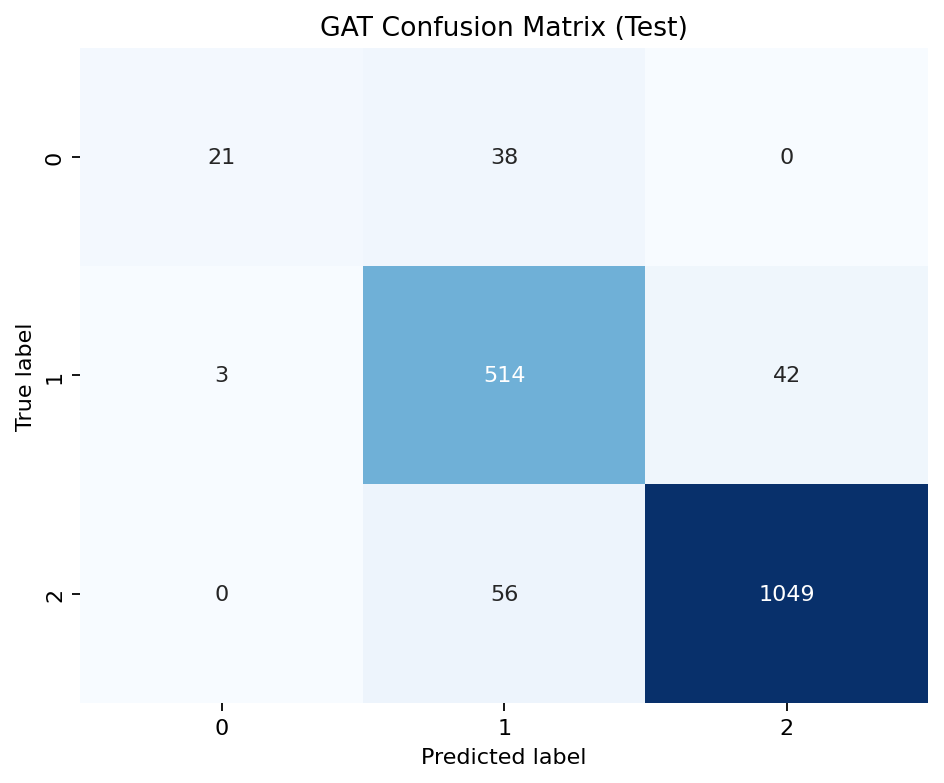

,0,1,2
0,21,38,0
1,3,514,42
2,0,56,1049


Classification report (test set):
              precision    recall  f1-score   support

           0     0.8750    0.3559    0.5060        59
           1     0.8454    0.9195    0.8809       559
           2     0.9615    0.9493    0.9554      1105

    accuracy                         0.9193      1723
   macro avg     0.8940    0.7416    0.7808      1723
weighted avg     0.9209    0.9193    0.9158      1723



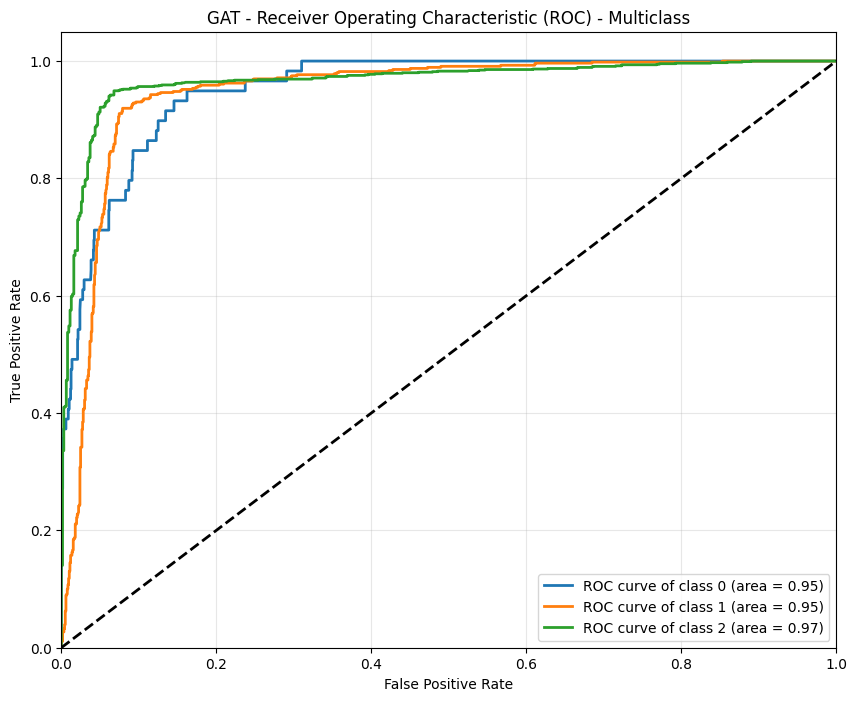

Saved: /kaggle/working/credit_rating_artifacts/gat_test_confusion_matrix.png
Saved: /kaggle/working/credit_rating_artifacts/gat_test_confusion_matrix.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_test_classification_report.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_test_roc_curves.png


In [7]:
id_to_raw_local = {v: k for k, v in raw_to_id.items()} if 'raw_to_id' in globals() else {i: i for i in range(n_classes)}
class_labels = [str(id_to_raw_local.get(i, i)) for i in range(n_classes)]
label_ids = list(range(n_classes))

cm = confusion_matrix(y_test, y_test_pred, labels=label_ids)
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)

plt.figure(figsize=(6, 5), dpi=160)
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('GAT Confusion Matrix (Test)')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
cm_plot_path = ARTIFACT_DIR / 'gat_test_confusion_matrix.png'
plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
plt.show()

display(cm_df)
print('Classification report (test set):')
print(classification_report(
    y_test,
    y_test_pred,
    labels=label_ids,
    target_names=class_labels,
    digits=4,
    zero_division=0,
))

cls_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_test_pred,
        labels=label_ids,
        target_names=class_labels,
        output_dict=True,
        zero_division=0,
    )
).transpose()

cm_csv_path = ARTIFACT_DIR / 'gat_test_confusion_matrix.csv'
cls_csv_path = ARTIFACT_DIR / 'gat_test_classification_report.csv'
cm_df.to_csv(cm_csv_path, encoding='utf-8-sig')
cls_report_df.to_csv(cls_csv_path, encoding='utf-8-sig')

plt.figure(figsize=(10, 8))
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc_val:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GAT - Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
roc_plot_path = ARTIFACT_DIR / 'gat_test_roc_curves.png'
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', cm_plot_path)
print('Saved:', cm_csv_path)
print('Saved:', cls_csv_path)
print('Saved:', roc_plot_path)


In [8]:
# Export prediction CSVs with the same contract as LSTM for DMF/DCS.

def prediction_frame(split_name, split_mask, y_true, proba):
    pred = np.argmax(proba, axis=1).astype(int)
    conf = np.max(proba, axis=1)
    rows = df.loc[split_mask.detach().cpu().numpy(), ['row_id', 'ticker', 'company_name', 'rating_date']].copy().reset_index(drop=True)
    rows.insert(0, 'split', split_name)
    rows['rating_date'] = pd.to_datetime(rows['rating_date'], errors='coerce').dt.strftime('%Y-%m-%d').fillna('')
    rows['true_label'] = y_true.astype(int)
    rows['true_label_name'] = [str(id_to_raw_local.get(int(y), y)) for y in y_true]
    rows['pred_label'] = pred
    rows['pred_label_name'] = [str(id_to_raw_local.get(int(y), y)) for y in pred]
    rows['confidence'] = conf.astype(float)
    for cls_idx in range(proba.shape[1]):
        rows[f'prob_{cls_idx}'] = proba[:, cls_idx].astype(float)
    return rows


gat_val_predictions = prediction_frame('val', val_mask, y_val, val_proba)
gat_test_predictions = prediction_frame('test', test_mask, y_test, test_proba)

val_csv = DMF_ARTIFACT_DIR / 'gat_val_predictions.csv'
test_csv = DMF_ARTIFACT_DIR / 'gat_test_predictions.csv'
gat_val_predictions.to_csv(val_csv, index=False, encoding='utf-8-sig')
gat_test_predictions.to_csv(test_csv, index=False, encoding='utf-8-sig')

np.save(DMF_ARTIFACT_DIR / 'gat_val_embeddings.npy', node_embeddings[val_mask].detach().cpu().numpy())
np.save(DMF_ARTIFACT_DIR / 'gat_test_embeddings.npy', node_embeddings[test_mask].detach().cpu().numpy())
np.save(ARTIFACT_DIR / 'gat_val_proba.npy', val_proba.astype(np.float32))
np.save(ARTIFACT_DIR / 'gat_test_proba.npy', test_proba.astype(np.float32))
np.save(ARTIFACT_DIR / 'gat_y_val.npy', y_val.astype(int))
np.save(ARTIFACT_DIR / 'gat_y_test.npy', y_test.astype(int))

label_contract.to_csv(DMF_ARTIFACT_DIR / 'label_mapping.csv', index=False, encoding='utf-8-sig')
print(f'[OK] Saved DMF val CSV  -> {val_csv}')
print(f'[OK] Saved DMF test CSV -> {test_csv}')
print(gat_test_predictions.head())


[OK] Saved DMF val CSV  -> /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/gat_val_predictions.csv
[OK] Saved DMF test CSV -> /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/gat_test_predictions.csv
  split       row_id ticker                   company_name rating_date  \
0  test  test_000040    AAL  American Airlines Group, Inc.  2013-11-12   
1  test  test_000815    AAP       ADVANCE AUTO PARTS, INC.  2013-05-29   
2  test  test_000326    AAP       Advance Auto Parts, Inc.  2013-11-25   
3  test  test_000813   AAPL                     Apple Inc.  2015-05-28   
4  test  test_000387   AAPL                     Apple Inc.  2016-06-03   

   true_label true_label_name  pred_label pred_label_name  confidence  \
0           1               1           1               1    0.743957   
1           2               2           2               2    0.978444   
2           2               2           2               2    0.956941   
3           2               2           2             

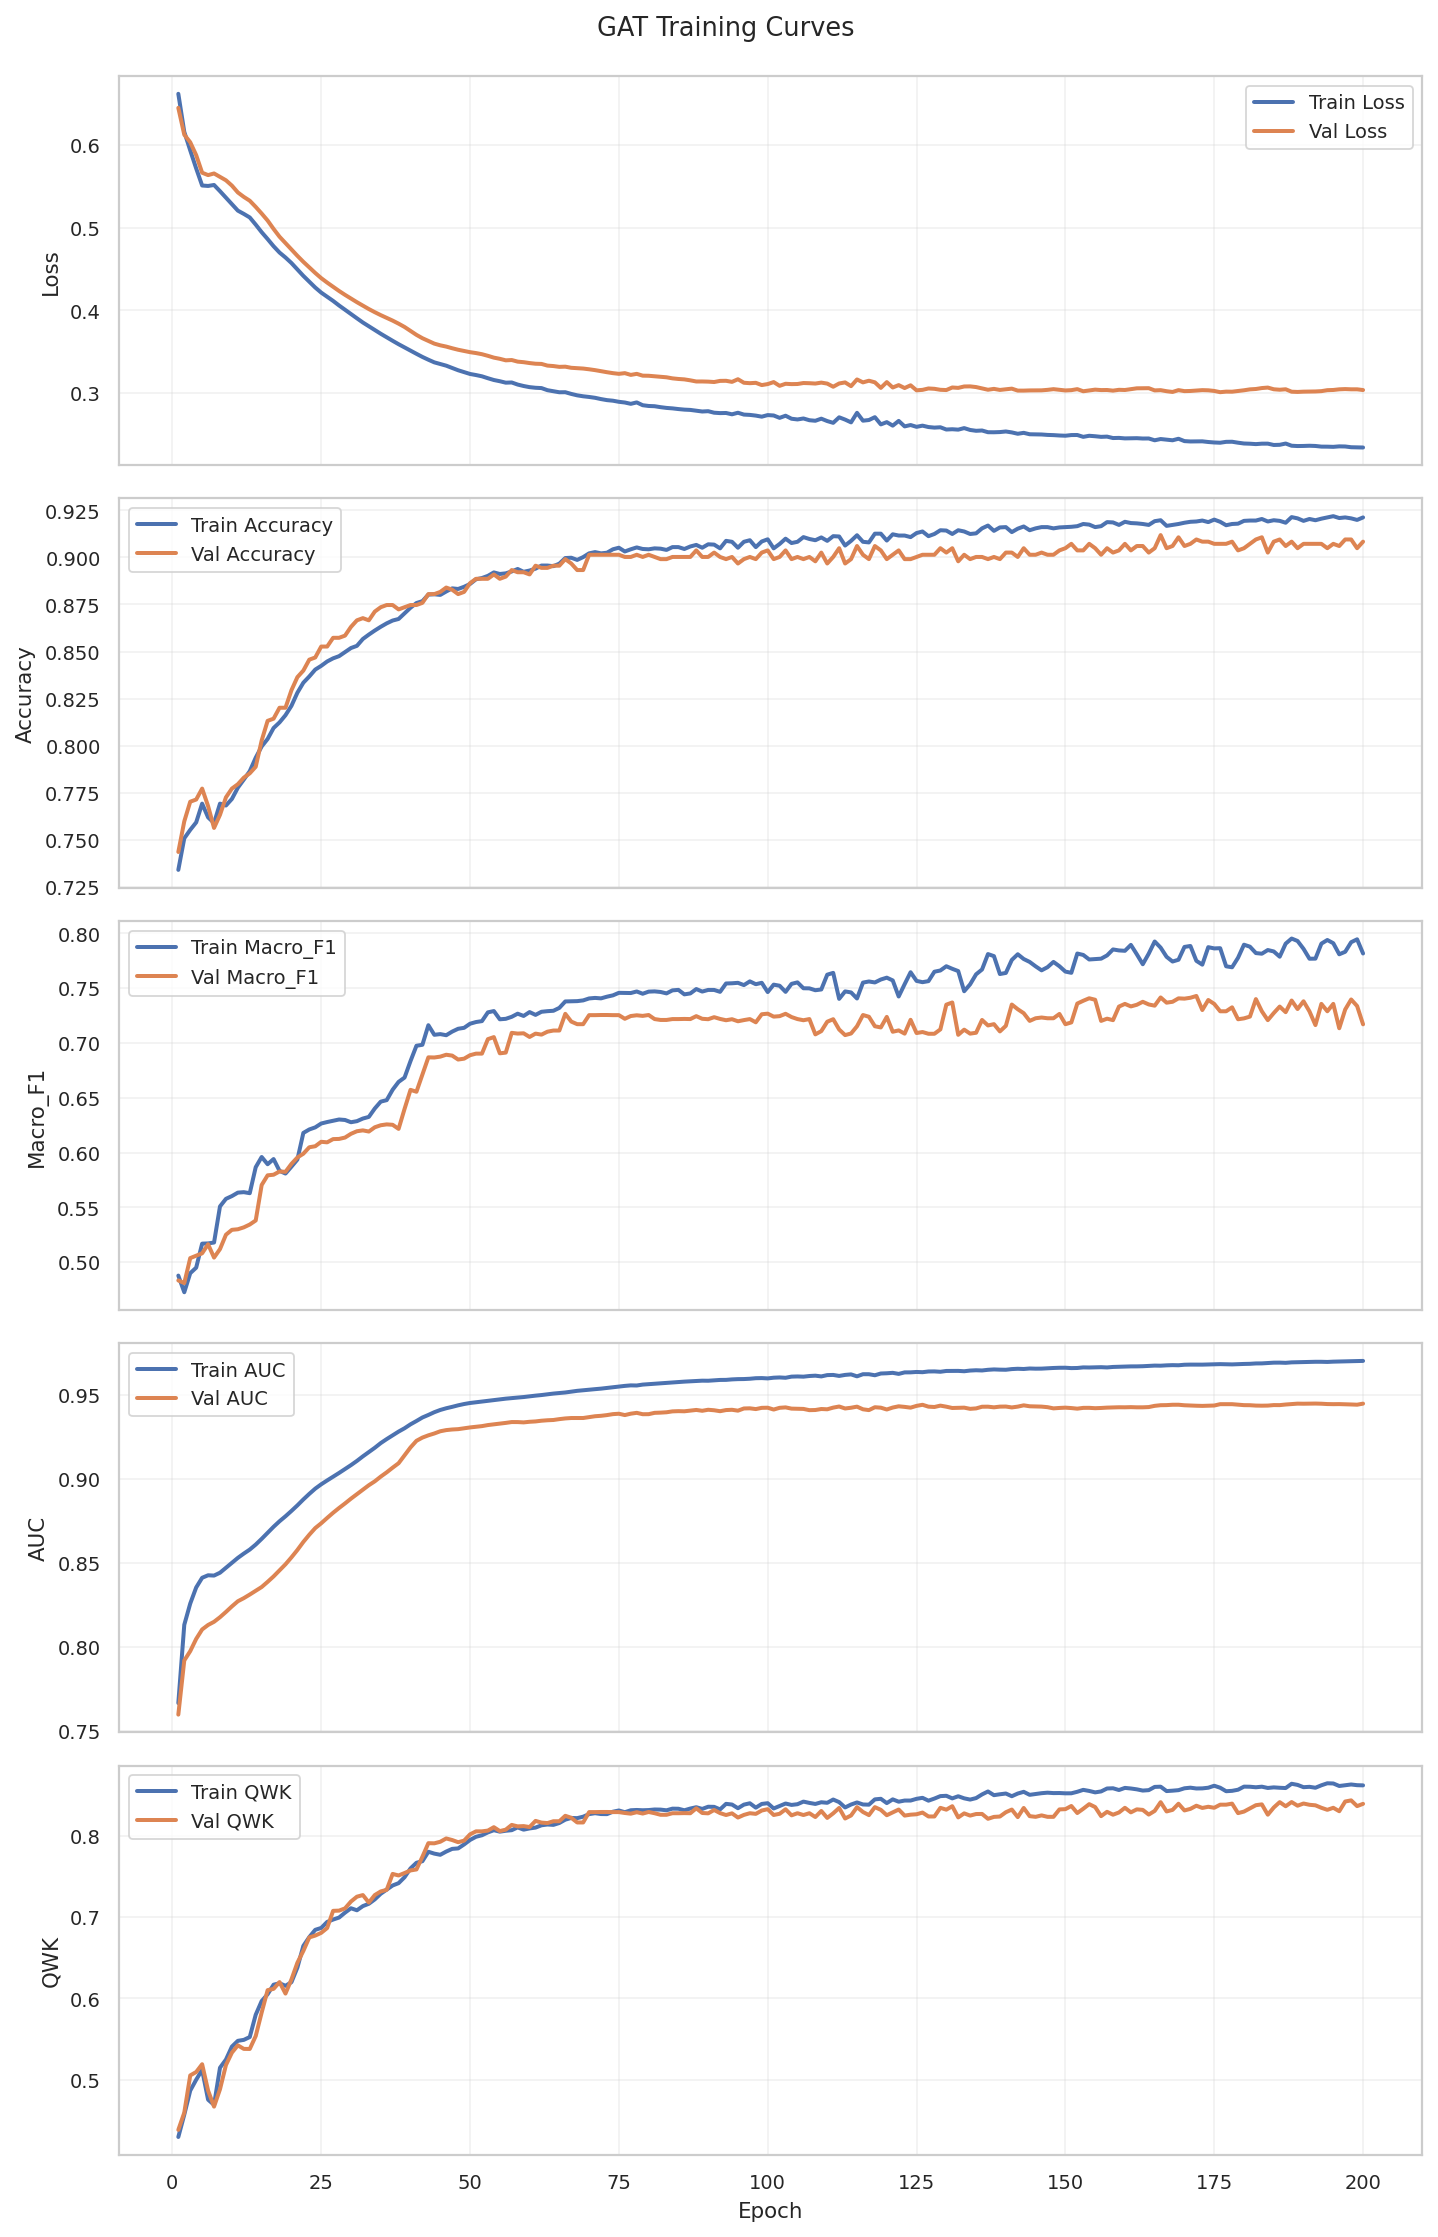

Saved: /kaggle/working/credit_rating_artifacts/gat_training_curves.png


In [9]:
# Visualization: training curves
if 'history_df' not in globals():
    raise RuntimeError('Khong tim thay history_df. Hay chay lai cell huan luyen truoc.')

sns.set_theme(style='whitegrid', context='paper')
metrics = ['Loss', 'Accuracy', 'Macro_F1', 'AUC', 'QWK']
fig, axes = plt.subplots(len(metrics), 1, figsize=(9, 14), dpi=160, sharex=True)
for ax, metric in zip(axes, metrics):
    ax.plot(history_df['epoch'], history_df[f'train_{metric}'], label=f'Train {metric}', linewidth=1.8)
    ax.plot(history_df['epoch'], history_df[f'val_{metric}'], label=f'Val {metric}', linewidth=1.8)
    ax.set_ylabel(metric)
    ax.legend(loc='best')
    ax.grid(alpha=0.25)
axes[-1].set_xlabel('Epoch')
fig.suptitle('GAT Training Curves', y=0.995)
plt.tight_layout()
curve_path = ARTIFACT_DIR / 'gat_training_curves.png'
plt.savefig(curve_path, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', curve_path)
